# Pricing US Flood Risk at underwriting

### SMM284 Applied Machine Learning Group 09


## 1. Setup

Formatter: `Black`


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn import set_config
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import TweedieRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap

# keep the notebook output clean
warnings.filterwarnings("ignore")
# show pipelines as diagrams
set_config(display="diagram")
# group 09 (ﾉ◕ヮ◕)ﾉ*:･ﾟ✧
RANDOM_STATE = 9
plt.rcParams["figure.figsize"] = (9, 4.5)
pd.set_option("display.max_columns", 40)
print("setup done")

setup done


In [39]:
# freeze environment -> requirements.txt
# (install with `pip install -r requirements.txt`)
import subprocess
import sys

# get exact Python executable running this notebook
python_exe = sys.executable

# -> pip freeze using this specific Python executable
result = subprocess.run(
    [python_exe, "-m", "pip", "freeze"], capture_output=True, text=True
)

# write to requirements.txt
with open("requirements.txt", "w") as f:
    f.write(result.stdout)

print("> requirements.txt generated.")

> requirements.txt generated.


## 2. Data acquisition - Federal Emergency Management Agency (FEMA) OpenFEMA (National Flood Insurance Program [NFIP] claims)

_See https://www.fema.gov/openfema-data-page/fima-nfip-redacted-policies-v2 for
additional background information_


In [40]:
# Data acquisition
# Source: FEMA OpenFEMA "FIMA NFIP Redacted Claims" v2
# (~2.72M rows, refreshed ~monthly). The metadata API is used only for the
# dataset descriptor and field schema. The records come from the bulk parquet,
# downloaded once and cached under data/raw/ with a 'provenance sidecar'.
#
# BE note: only learned the term provenance sidecar through this project
#   "a provenance sidecar is a specialized design pattern used to track and 
#   verify the history of software artifacts without burdening the application 
#   code itself."
from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import requests

# --- Endpoints -------------------------------------------------------------
METADATA_BASE = "https://www.fema.gov/api/open/v1"
DATA_API = "https://www.fema.gov/api/open/v2/FimaNfipClaims"
DATASET_NAME = "FimaNfipClaims"
DATASET_VERSION = 2

RAW_DIR = Path("data/raw")
RAW_PARQUET = RAW_DIR / "FimaNfipClaimsV2.parquet"
PROVENANCE = RAW_DIR / "provenance.json"

# --- Column contract (the leakage boundary) --------------------------------
TARGET = "amountPaidOnBuildingClaim"

# Known at underwriting time -> legal features for a pricing model
UNDERWRITING_FEATURES = [
    "ratedFloodZone",
    "elevationDifference",
    "baseFloodElevation",
    "lowestFloorElevation",
    "lowestAdjacentGrade",
    "elevatedBuildingIndicator",
    "basementEnclosureCrawlspaceType",
    "obstructionType",
    "occupancyType",
    "numberOfFloorsInTheInsuredBuilding",
    "buildingDescriptionCode",
    "condominiumCoverageTypeCode",
    "postFIRMConstructionIndicator",
    "originalConstructionDate",
    "primaryResidenceIndicator",
    "rentalPropertyIndicator",
    "totalBuildingInsuranceCoverage",
    "totalContentsInsuranceCoverage",
    "buildingDeductibleCode",
    "crsClassificationCode",
    "elevationCertificateIndicator",
]

# Known only after the flood -> leakage for a pricing model
# can't use as features
# BE note: this dataset contains just flooded properties, but some have a 0
# claim amount
POST_FLOOD_FIELDS = [
    "waterDepth",
    "floodWaterDuration",
    "floodCharacteristicsIndicator",
    "causeOfDamage",
    "floodEvent",
    "eventDesignationNumber",
    "ficoNumber",
    "buildingDamageAmount",
    "contentsDamageAmount",
    "amountPaidOnContentsClaim",
    "netBuildingPaymentAmount",
    "netContentsPaymentAmount",
    "replacementCostBasis",
    "nonPaymentReasonBuilding",
    "nonPaymentReasonContents",
]

# Geography + time for EDA
# includes the zone/state baseline, and grouped CV splits
CONTEXT = [
    "state",
    "countyCode",
    "yearOfLoss",
    "dateOfLoss",
    "latitude",
    "longitude",
]

# Diagnostic fields for the under-insurance rider (not pricing features)
RIDER = ["buildingReplacementCost", "buildingPropertyValue"]

# what to load from parquet
# (target + legal features + context + rider)
LOAD_COLUMNS = [TARGET] + UNDERWRITING_FEATURES + CONTEXT + RIDER


# --- Metadata API ----------------------------------------------------------
def _get_json(path: str, params: dict) -> dict:
    """GET a small OpenFEMA metadata payload as JSON."""
    resp = requests.get(f"{METADATA_BASE}/{path}", params=params, timeout=60)
    resp.raise_for_status()
    return resp.json()


def get_dataset_metadata() -> dict:
    """Dataset descriptor: bulk file URLs, record count, refresh stamp, hash."""
    payload = _get_json("OpenFemaDataSets", {"$filter": f"name eq '{DATASET_NAME}'"})
    ds = payload["OpenFemaDataSets"][0]
    dist = {d["format"]: d["accessURL"] for d in ds["distribution"]}
    return {
        "record_count": ds["recordCount"],
        "parquet_url": dist["parquet"],
        "csv_url": dist["csv"],
        "last_refresh": ds["lastDataSetRefresh"],
        "hash": ds["hash"],
        "version": ds["version"],
    }


def get_field_schema() -> pd.DataFrame:
    """Field dictionary as a DataFrame (name, type, description, key, nullable)."""
    payload = _get_json(
        "OpenFemaDataSetFields",
        {
            "$filter": f"openFemaDataSet eq '{DATASET_NAME}' "
            f"and datasetVersion eq {DATASET_VERSION}"
        },
    )
    fields = pd.DataFrame(payload["OpenFemaDataSetFields"])
    return fields[["name", "type", "description", "primaryKey", "isNullable"]]


# --- Bulk download + load --------------------------------------------------
def download_raw(force: bool = False) -> Path:
    """Download the bulk Parquet once into data/raw/; skip if already cached.

    Writes a provenance.json sidecar (source URL, FEMA hash, expected row
    count, download time) so the run is reproducible and auditable.
    """
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    if RAW_PARQUET.exists() and not force:
        return RAW_PARQUET

    meta = get_dataset_metadata()
    print(f"Downloading bulk parquet (~50-500 MB):\n  {meta['parquet_url']}")
    with requests.get(meta["parquet_url"], stream=True, timeout=600) as r:
        r.raise_for_status()
        with open(RAW_PARQUET, "wb") as fh:
            for chunk in r.iter_content(chunk_size=1 << 20):  # 1 MB chunks
                fh.write(chunk)

    PROVENANCE.write_text(
        json.dumps(
            {
                "parquet_url": meta["parquet_url"],
                "fema_hash": meta["hash"],
                "expected_record_count": meta["record_count"],
                "last_refresh": meta["last_refresh"],
                "downloaded_at": datetime.now(timezone.utc).isoformat(),
            },
            indent=2,
        )
    )
    print(f"Saved -> {RAW_PARQUET}")
    return RAW_PARQUET


def load_raw(
    columns: list[str] | None = LOAD_COLUMNS, validate: bool = True
) -> pd.DataFrame:
    """Load the cached Parquet (default: the project's ~30 columns via pushdown).

    Pass columns=None to load all 73 fields. Row count is checked against the
    recorded provenance as a soft warning (FEMA refreshes monthly, so a drift
    is informative, not an error).
    """
    path = download_raw()
    df = pd.read_parquet(path, columns=columns, engine="pyarrow")

    if validate and PROVENANCE.exists():
        expected = json.loads(PROVENANCE.read_text())["expected_record_count"]
        if len(df) != expected:
            print(
                f"NOTE: loaded {len(df):,} rows; provenance expected "
                f"{expected:,}. FEMA likely refreshed the file — "
                f"re-run download_raw(force=True) to re-pin provenance."
            )
    return df


# --- Small API slice (for quick dev / building the shared fixture) ---------
def fetch_api_sample(n: int = 1000, where: str | None = None) -> pd.DataFrame:
    """Pull up to n rows via the v2 data API (paged in 1,000s).

    Use for fast iteration or to build the committed dev fixture, e.g.
    fetch_api_sample(2000, where="state eq 'TX' and yearOfLoss eq 2017").
    Do NOT use this to assemble the full dataset — use the bulk parquet.
    """
    rows, skip, page = [], 0, min(n, 1000)
    while len(rows) < n:
        params = {"$top": page, "$skip": skip, "$format": "json"}
        if where:
            params["$filter"] = where
        resp = requests.get(DATA_API, params=params, timeout=120)
        resp.raise_for_status()
        batch = resp.json().get(DATASET_NAME, [])
        if not batch:
            break
        rows.extend(batch)
        skip += page
    return pd.DataFrame(rows[:n])

In [41]:
# Sample fixture
#   cut a small, representative parquet slice for fast testing
# Stratified by state x decade, with the known edge cases forced in so every
# cleaning code path is exercised even on the small slice.
# Note: Building it requires the full parquet (downloaded if absent).
SAMPLE_PARQUET = Path("data/sample/nfip_sample.parquet")


def build_sample(target_rows: int = 30_000, seed: int = 284) -> Path:
    """Build the committed sample slice from the full parquet."""
    SAMPLE_PARQUET.parent.mkdir(parents=True, exist_ok=True)
    # all cols, including 'id'
    full = pd.read_parquet(download_raw(), engine="pyarrow")
    print(f"full: {len(full):,} rows x {full.shape[1]} cols")

    # Strata key as a standalone Series
    #   -> never added to full, nothing to drop later
    decade = pd.to_numeric(full["yearOfLoss"], errors="coerce") // 10 * 10
    strata_key = (
        full["state"].astype("string").fillna("NA")
        + "_"
        + decade.astype("string").fillna("NA")
    )

    frac = min(1.0, target_rows / len(full))

    # Proportional sample per stratum, min 1 per group
    # group_keys=False keeps it flat
    sample = (
        full.groupby(strata_key, group_keys=False)
        .apply(lambda g: g.sample(max(1, int(round(len(g) * frac))), random_state=seed))
        .reset_index(drop=True)
    )

    # Guarantee the known edge cases are present (don't rely on luck)
    def force_in(sample, mask, n, label):
        extra = full.loc[mask]
        if len(extra):
            add = extra.sample(min(n, len(extra)), random_state=seed)
            sample = pd.concat([sample, add]).drop_duplicates(subset="id")
            print(f"  +{min(n, len(extra))} {label}")
        return sample

    bld = pd.to_numeric(full["amountPaidOnBuildingClaim"], errors="coerce")
    sample = force_in(sample, bld < 0, 50, "negative payouts")
    sample = force_in(sample, bld == 0, 200, "zero/denied payouts")
    sample = force_in(
        sample,
        pd.to_numeric(full["elevationDifference"], errors="coerce") == 9999,
        200,
        "elev 9999 sentinels",
    )
    sample = force_in(
        sample,
        pd.to_numeric(full["occupancyType"], errors="coerce") >= 11,
        200,
        "Risk Rating 2.0 codes",
    )
    sample = force_in(
        sample,
        pd.to_numeric(full["yearOfLoss"], errors="coerce") < 1996,
        200,
        "pre-1996 records",
    )

    # shuffle
    sample = sample.sample(frac=1, random_state=seed).reset_index(drop=True)
    sample.to_parquet(SAMPLE_PARQUET, engine="pyarrow", compression="zstd")

    mb = SAMPLE_PARQUET.stat().st_size / 1e6
    print(
        f"wrote {SAMPLE_PARQUET}: {len(sample):,} rows x {sample.shape[1]} cols, {mb:.2f} MB"
    )
    if mb > 2.0:
        print("Above ~2 MB — re-run with target_rows=15_000 (zstd already on).")
    return SAMPLE_PARQUET

In [ ]:
# --- data selection toggle ---------------------------------------------------
# True  -> ~30k-row representative slice: fast, for testing the pipeline
#          end-to-end before leaving the tuning to run
# False -> full dataset (~2.7M rows): the real run
USE_SAMPLE = False

# BE note: at Bayes library the full download takes ~15.4 seconds

if USE_SAMPLE:
    if not SAMPLE_PARQUET.exists():
        # blank directory: builds the slice 
        # (downloads the full parquet first if it is also missing)
        build_sample()
    DATA_PATH = SAMPLE_PARQUET
else:
    download_raw()  # no-op if already cached
    DATA_PATH = RAW_PARQUET

# same column pushdown for both, so df has an identical shape in either mode
df = pd.read_parquet(DATA_PATH, columns=LOAD_COLUMNS, engine="pyarrow")

mode = "SAMPLE (testing)" if USE_SAMPLE else "FULL"
print(
    f"mode: {mode}   loaded {DATA_PATH}  ->  rows: {len(df):,}   columns: {df.shape[1]}"
)
df.head(3)

mode: SAMPLE (testing)   loaded data/sample/nfip_sample.parquet  ->  rows: 30,660   columns: 30


,amountPaidOnBuildingClaim,ratedFloodZone,elevationDifference,baseFloodElevation,lowestFloorElevation,lowestAdjacentGrade,elevatedBuildingIndicator,basementEnclosureCrawlspaceType,obstructionType,occupancyType,numberOfFloorsInTheInsuredBuilding,buildingDescriptionCode,condominiumCoverageTypeCode,postFIRMConstructionIndicator,originalConstructionDate,primaryResidenceIndicator,rentalPropertyIndicator,totalBuildingInsuranceCoverage,totalContentsInsuranceCoverage,buildingDeductibleCode,crsClassificationCode,elevationCertificateIndicator,state,countyCode,yearOfLoss,dateOfLoss,latitude,longitude,buildingReplacementCost,buildingPropertyValue
0,None,A05,None,None,None,None,True,2.0,60.0,1.0,2.0,NaN,N,False,1952-07-01,True,False,134600.0,0.0,2,NaN,1,VA,51735,1999,1999-12-16,37.1,-76.4,82236.0,65788.0
1,3202.76,AE,None,None,None,None,False,1.0,NaN,1.0,2.0,NaN,N,False,1955-01-01,True,False,153700.0,10400.0,2,NaN,NaN,IL,17031,2008,2008-09-12,41.9,-87.9,98672.0,46376.0
2,360.07,A,None,None,None,None,False,NaN,10.0,4.0,1.0,NaN,N,False,1492-10-12,False,False,100000.0,100000.0,0,NaN,1,PA,42071,1979,1979-08-30,40.0,-76.0,0.0,319400.0


In [43]:
schema = get_field_schema()  # name / type / description / key / nullable
schema.head()

,name,type,description,primaryKey,isNullable
0,asOfDate,datetime,The effective date of the data in the file. In...,False,True
1,amountPaidOnBuildingClaim,"decimal(12,2)",Dollar amount paid on the building claim. In s...,False,True
2,amountPaidOnContentsClaim,"decimal(12,2)",Dollar amount paid on the contents claim. In s...,False,True
3,amountPaidOnIncreasedCostOfComplianceClaim,"decimal(12,2)",ICC coverage is one of several flood insurance...,False,True
4,netBuildingPaymentAmount,"decimal(12,2)",Net building payment amount made to insured in...,False,True


## 3. Initial look


In [44]:
display(df.dtypes)
# sparsest columns first
df.isna().mean().sort_values(ascending=False).head(20)

amountPaidOnBuildingClaim              object
ratedFloodZone                            str
elevationDifference                    object
baseFloodElevation                     object
lowestFloorElevation                   object
lowestAdjacentGrade                    object
elevatedBuildingIndicator                bool
basementEnclosureCrawlspaceType       float64
obstructionType                       float64
occupancyType                         float64
numberOfFloorsInTheInsuredBuilding    float64
buildingDescriptionCode               float64
condominiumCoverageTypeCode               str
postFIRMConstructionIndicator            bool
originalConstructionDate               object
primaryResidenceIndicator                bool
rentalPropertyIndicator                  bool
totalBuildingInsuranceCoverage        float64
totalContentsInsuranceCoverage        float64
buildingDeductibleCode                    str
crsClassificationCode                 float64
elevationCertificateIndicator     

crsClassificationCode                 0.950294
lowestAdjacentGrade                   0.810176
elevationCertificateIndicator         0.776419
lowestFloorElevation                  0.765068
baseFloodElevation                    0.756556
elevationDifference                   0.730724
basementEnclosureCrawlspaceType       0.696347
buildingDescriptionCode               0.637280
obstructionType                       0.443901
buildingReplacementCost               0.221787
buildingPropertyValue                 0.221755
amountPaidOnBuildingClaim             0.206784
buildingDeductibleCode                0.102022
ratedFloodZone                        0.051957
countyCode                            0.022798
longitude                             0.014938
latitude                              0.014938
condominiumCoverageTypeCode           0.014547
numberOfFloorsInTheInsuredBuilding    0.006915
originalConstructionDate              0.000881
dtype: float64

count     24320
unique    20489
top        0.00
freq       1885
Name: amountPaidOnBuildingClaim, dtype: object
zero payouts: 6.1%
negative payouts: 50


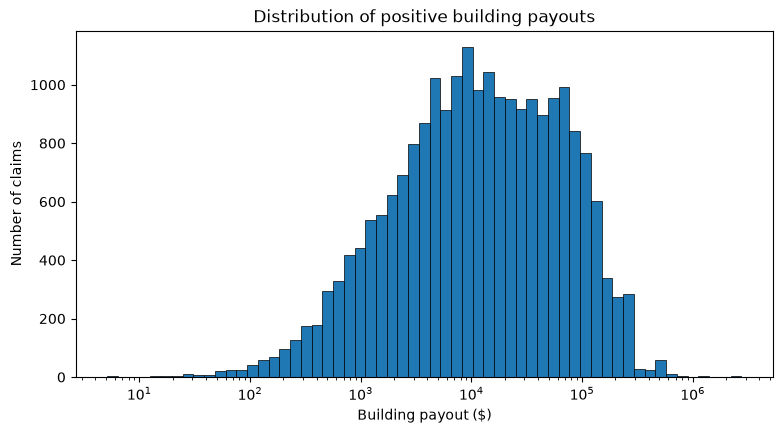

In [45]:
print(df[TARGET].describe())
# denied / no building payment
print(f"zero payouts: {(df[TARGET] == 0).mean():.1%}")
# re-issued cheques
print(f"negative payouts: {(df[TARGET] < 0).sum():,}")

# positive payouts
pos = df[df[TARGET] > 0][TARGET].astype(float)
# calc bins and counts using numpy (faster)
bins = np.logspace(np.log10(pos.min()), np.log10(pos.max()), 60)
counts, edges = np.histogram(pos, bins=bins)
# plt.stairs(counts, edges, fill=True)
plt.bar(
    x=edges[:-1],
    height=counts,
    width=np.diff(edges),
    align="edge",
    edgecolor="black",
    linewidth=0.5,
)
plt.xscale("log")
plt.xlabel("Building payout ($)")
plt.ylabel("Number of claims")
plt.title("Distribution of positive building payouts")
plt.show()

In [71]:
# check for missing values where "9999" was entered to show it was missing
for col in ["elevationDifference", "baseFloodElevation"]:
    is_sentinel = pd.to_numeric(df[col], errors="coerce").abs() >= 9990
    print(f"{col} sentinel (±9999): {is_sentinel.sum():,} ({is_sentinel.mean():.1%})")

print("\nOccupancy Type:")
print(df["occupancyType"].value_counts().head(12).apply(lambda x: f"{x:,}"))
# 1-digit legacy vs 2-digit Risk Rating 2.0
print(df["ratedFloodZone"].value_counts().head(12).apply(lambda x: f"{x:,}"))

elevationDifference sentinel (±9999): 0 (0.0%)
baseFloodElevation sentinel (±9999): 0 (0.0%)

Occupancy Type:
occupancyType
1.0     20,080
11.0     4,770
4.0      1,906
2.0      1,468
3.0        863
18.0       434
15.0       323
6.0        285
12.0       208
16.0       121
14.0       109
13.0        82
Name: count, dtype: str
ratedFloodZone
AE     10,554
X       4,643
A       2,288
C       1,852
B       1,255
A04       608
A01       582
VE        560
A05       530
A06       526
A08       497
A07       465
Name: count, dtype: str


In [73]:
cols = ["elevationDifference", "baseFloodElevation", "lowestFloorElevation", "lowestAdjacentGrade"]
full = pd.read_parquet(RAW_PARQUET, columns=cols, engine="pyarrow")
for c in cols:
    v = pd.to_numeric(full[c], errors="coerce")
    print(f"{c:32s} missing {v.isna().mean():5.1%}   "
          f"min {v.min():>10,.1f}   max {v.max():>10,.1f}   |v|>=9990: {(v.abs() >= 9990).sum():,}")
    print("   largest:", v.nlargest(3).round(1).tolist(), "  smallest:", v.nsmallest(3).round(1).tolist())

elevationDifference              missing 73.0%   min   -9,989.0   max      998.0   |v|>=9990: 0
   largest: [998.0, 998.0, 990.0]   smallest: [-9989.0, -9980.0, -9980.0]
baseFloodElevation               missing 75.7%   min   -9,999.0   max    9,998.0   |v|>=9990: 3,371
   largest: [9998.0, 9991.0, 9990.0]   smallest: [-9999.0, -9999.0, -9999.0]
lowestFloorElevation             missing 76.4%   min   -9,999.0   max    9,998.9   |v|>=9990: 1,415
   largest: [9998.9, 9998.0, 9998.0]   smallest: [-9999.0, -9999.0, -9999.0]
lowestAdjacentGrade              missing 81.1%   min  -99,999.9   max    9,998.9   |v|>=9990: 289
   largest: [9998.9, 9998.9, 9998.9]   smallest: [-99999.9, -99999.9, -99999.9]


In [47]:
print("Missing (NaN) values in Underwriting Features:")

# Calculate the number of missing values per column
missing_counts = df[UNDERWRITING_FEATURES].isna().sum()

# Filter for columns that actually have missing data, and sort highest to lowest
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

# Print the formatted results
for col, count in missing_counts.items():
    pct = count / len(df)
    print(f"{col}: \t{count:,} \t({pct:.1%})")

Missing (NaN) values in Underwriting Features:
crsClassificationCode: 	29,136 	(95.0%)
lowestAdjacentGrade: 	24,840 	(81.0%)
elevationCertificateIndicator: 	23,805 	(77.6%)
lowestFloorElevation: 	23,457 	(76.5%)
baseFloodElevation: 	23,196 	(75.7%)
elevationDifference: 	22,404 	(73.1%)
basementEnclosureCrawlspaceType: 	21,350 	(69.6%)
buildingDescriptionCode: 	19,539 	(63.7%)
obstructionType: 	13,610 	(44.4%)
buildingDeductibleCode: 	3,128 	(10.2%)
ratedFloodZone: 	1,593 	(5.2%)
condominiumCoverageTypeCode: 	446 	(1.5%)
numberOfFloorsInTheInsuredBuilding: 	212 	(0.7%)
originalConstructionDate: 	27 	(0.1%)
occupancyType: 	8 	(0.0%)


## 4. Cleaning and claim selection


In [48]:
# text -> numeric (including payout target)
num_coerce = [
    "amountPaidOnBuildingClaim",
    "totalBuildingInsuranceCoverage",
    "totalContentsInsuranceCoverage",
    "elevationDifference",
    "baseFloodElevation",
    "lowestFloorElevation",
    "lowestAdjacentGrade",
    "buildingReplacementCost",
    "crsClassificationCode",
    "numberOfFloorsInTheInsuredBuilding",
]
for c in num_coerce:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# elevation 'not reported' (9999 / -9999) -> NaN
for c in [
    "elevationDifference",
    "baseFloodElevation",
    "lowestFloorElevation",
    "lowestAdjacentGrade",
]:
    df.loc[df[c].abs() >= 9990, c] = np.nan

# Trim large values for building age at loss
build_year = pd.to_datetime(df["originalConstructionDate"], errors="coerce").dt.year
df["building_age"] = (df["yearOfLoss"] - build_year).where(
    lambda s: (s >= 0) & (s <= 200)
)

# deductible code -> $ amount
ded_map = {
    "0": 500,
    "1": 1000,
    "2": 2000,
    "3": 3000,
    "4": 4000,
    "5": 5000,
    "9": 750,
    "A": 10000,
    "B": 15000,
    "C": 20000,
    "D": 25000,
    "E": 50000,
    "F": 1250,
    "G": 1500,
    "H": 200,
}
df["deductible_amount"] = df["buildingDeductibleCode"].map(ded_map)

# occupancy cleaning: legacy (1-6) + Risk Rating 2.0 (11-19) -> one set of classes
occ_map = {
    1: "single_family",
    11: "single_family",
    2: "2to4_family",
    12: "2to4_family",
    3: "multi_family",
    13: "multi_family",
    4: "non_residential",
    6: "non_residential",
    18: "non_residential",
    19: "non_residential",
    14: "mobile_home",
    17: "mobile_home",
    15: "condo",
    16: "condo",
}
df["occupancy_class"] = df["occupancyType"].map(occ_map).fillna("other")


# put flood zone into risk families
def zone_family(z):
    if not isinstance(z, str) or z.strip() == "":
        return "Unknown"
    z = z.upper()
    if z.startswith("V"):
        return "V (velocity)"
    if z.startswith("A"):
        return "A (SFHA no BFE)" if z == "A" else "A (SFHA w/ BFE)"
    if z[0] in {"X", "B", "C"}:
        return "X/B/C (moderate-min)"
    if z == "D":
        return "D (undetermined)"
    return "Unknown"


df["zone_family"] = df["ratedFloodZone"].map(zone_family)

# codes cleaning RE categories.
# booleans -> 0/1
df["floors_cat"] = (
    df["numberOfFloorsInTheInsuredBuilding"]
    .astype("Int64")
    .astype("string")
    .fillna("missing")
)
df["basement_cat"] = (
    df["basementEnclosureCrawlspaceType"]
    .astype("Int64")
    .astype("string")
    .fillna("missing")
)
for b in [
    "postFIRMConstructionIndicator",
    "elevatedBuildingIndicator",
    "primaryResidenceIndicator",
]:
    df[b + "_i"] = df[b].astype("int8")

# setting up model
# Just want positive building claims (print decision log)
t = df["amountPaidOnBuildingClaim"]
print("SELECTION LOG")
print(f"  total rows      : {len(df):,}")
print(f"  positive payout : {int((t > 0).sum()):,}   <- kept (the severity model)")
print(f"  zero / denied   : {int((t == 0).sum()):,}")
print(f"  negative        : {int((t < 0).sum()):,}")
print(f"  missing         : {int(t.isna().sum()):,}")
model_df = df[t > 0].copy()
print(f"  -> modelling rows: {len(model_df):,}")

SELECTION LOG
  total rows      : 30,660
  positive payout : 22,385   <- kept (the severity model)
  zero / denied   : 1,885
  negative        : 50
  missing         : 6,340
  -> modelling rows: 22,385


## 5. Inflation adjustment — constant 2024 USD


In [49]:
from pathlib import Path
import io, json, requests
from datetime import datetime, timezone

CPI_CSV = Path("data/raw/cpiaucsl.csv")
CPI_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL"
REF_YEAR = 2024
# last complete CPI year
# BE note: there's one missing entry for 2025 in October.
# Decided to go for 2024 here, rather than have one month missing...


def load_cpi_annual() -> pd.Series:
    """Annual-average CPI-U, cached locally after the first download."""
    if not CPI_CSV.exists():
        CPI_CSV.parent.mkdir(parents=True, exist_ok=True)
        r = requests.get(CPI_URL, timeout=60)
        r.raise_for_status()
        CPI_CSV.write_bytes(r.content)
        CPI_CSV.with_suffix(".provenance.json").write_text(
            json.dumps(
                {
                    "source": CPI_URL,
                    "series": "CPIAUCSL (BLS via FRED)",
                    "downloaded_at": datetime.now(timezone.utc).isoformat(),
                },
                indent=2,
            )
        )
    cpi = pd.read_csv(CPI_CSV)
    date_col = cpi.columns[0]  # FRED has used both DATE and observation_date
    cpi[date_col] = pd.to_datetime(cpi[date_col])
    cpi["CPIAUCSL"] = pd.to_numeric(cpi["CPIAUCSL"], errors="coerce")
    annual = cpi.set_index(date_col)["CPIAUCSL"].resample("YE").mean()
    annual.index = annual.index.year
    return annual.dropna()


cpi_annual = load_cpi_annual()

# deflator: multiply a year-y dollar amount by factor[y] to express it in
# REF_YEAR dollars
factor = (cpi_annual.loc[REF_YEAR] / cpi_annual).rename("cpi_factor")

MONEY_COLS = [
    "amountPaidOnBuildingClaim",  # the target
    "totalBuildingInsuranceCoverage",
    "totalContentsInsuranceCoverage",
    "deductible_amount",
    "buildingReplacementCost",
]

# map each claim's loss year to a factor; years outside the CPI table (if the
# FEMA refresh runs ahead of the CPI cache) fall back to the latest factor
f = model_df["yearOfLoss"].map(factor).fillna(factor.iloc[-1])
model_df["cpi_factor"] = f

# idempotent: deflate from a preserved *_nominal copy, so re-running this cell
# (or changing REF_YEAR) never compounds the adjustment
for c in MONEY_COLS:
    if c in model_df.columns:
        nom = c + "_nominal"
        if nom not in model_df.columns:
            # keep the nominal original once
            model_df[nom] = model_df[c]
        model_df[c] = model_df[nom] * f

print(f"Deflated {len(MONEY_COLS)} monetary columns to constant {REF_YEAR} USD.")
print(
    f"Example factors: 1980 -> x{factor.get(1980, float('nan')):.2f}, "
    f"2000 -> x{factor.get(2000, float('nan')):.2f}, "
    f"2020 -> x{factor.get(2020, float('nan')):.2f}"
)
print(
    f"Median real severity: ${model_df['amountPaidOnBuildingClaim'].median():,.0f} ({REF_YEAR} USD)"
)

Deflated 5 monetary columns to constant 2024 USD.
Example factors: 1980 -> x3.81, 2000 -> x1.82, 2020 -> x1.21
Median real severity: $21,080 (2024 USD)


## 6. Exploratory data analysis (EDA)

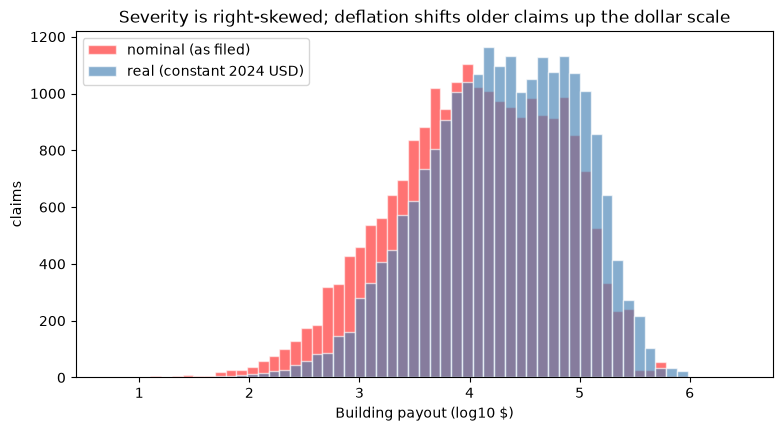

nominal: median $  12,047,   mean: $  36,313,   max: $ 2,749,032
real:    median $  21,080,   mean: $  52,765,   max: $ 2,946,987


In [50]:
# EDA
# payout distribution is right-skewed -> log-link
# Real (2024 USD) vs nominal on the SAME axes.
# deflation shifts the older, smaller-dollar claims up and tightens the left 
# tail. The skew survives in both
real = model_df["amountPaidOnBuildingClaim"]
nominal = model_df["amountPaidOnBuildingClaim_nominal"]

bins = np.linspace(
    np.log10(min(real.min(), nominal.min())),
    np.log10(max(real.max(), nominal.max())),
    60,
)
plt.hist(
    np.log10(nominal),
    bins=bins,
    color="red",
    alpha=0.55,
    edgecolor="white",
    label="nominal (as filed)",
)
plt.hist(
    np.log10(real),
    bins=bins,
    color="steelblue",
    alpha=0.65,
    edgecolor="white",
    label="real (constant 2024 USD)",
)
plt.xlabel("Building payout (log10 $)")
plt.ylabel("claims")
plt.title("Severity is right-skewed; deflation shifts older claims up the dollar scale")
plt.legend()
plt.show()

print(f"nominal: median ${nominal.median():>8,.0f},", end="   ")
print(f"mean: ${nominal.mean():>8,.0f},", end="   ")
print(f"max: ${nominal.max():>10,.0f}")

print(f"real:    median ${real.median():>8,.0f},", end="   ")
print(f"mean: ${real.mean():>8,.0f},", end="   ")
print(f"max: ${real.max():>10,.0f}")

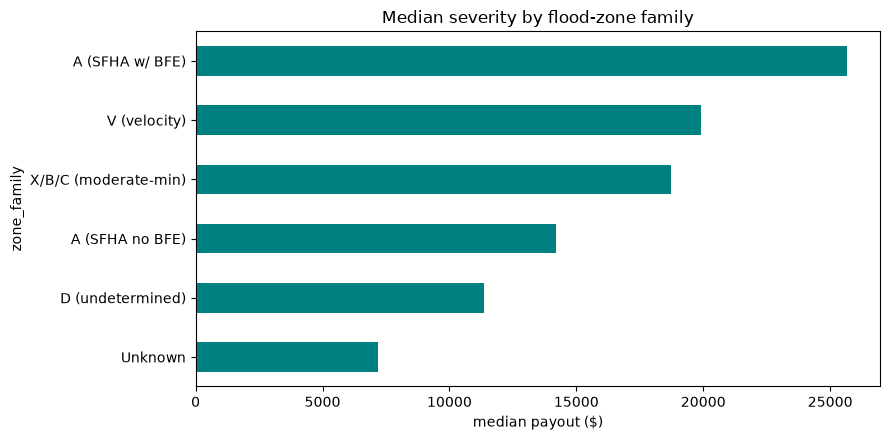

In [51]:
# median severity by flood-zone family
# the legacy zone scheme captures *some* signal (our baseline)
order = (
    model_df.groupby("zone_family")["amountPaidOnBuildingClaim"].median().sort_values()
)
order.plot(kind="barh", color="teal")
plt.xlabel("median payout ($)")
plt.title("Median severity by flood-zone family")
plt.tight_layout()
plt.show()

# Notes:
# put FEMA's zone codes (A01–A30, etc.) into six buckets:
# V (velocity) - any zone starting with V.
#   Coastal high-hazard areas exposed to wave action (most dangerous)
# A (SFHA w/ BFE)
#   zones starting with A that have a specific number (A01–A30, AE, etc.)
#   Special Flood Hazard Area with a Base Flood Elevation on record
# A (SFHA no BFE)
#   bare "A" zone.
#   Special Flood Hazard Area without an established Base Flood Elevation.
# X/B/C (moderate-min)
#   zones starting with X, B, or C.
#   Moderate-to-minimal risk, outside the 100-year floodplain.
# D (undetermined)
#   zone D. Risk exists but hasn't been assessed.
# Unknown
#   blank, missing, or anything that doesn't match the above.

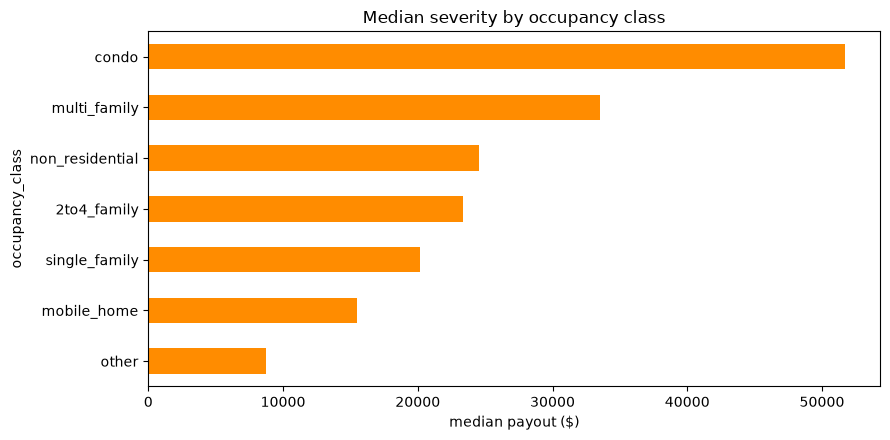

In [52]:
# occupancy class
model_df.groupby("occupancy_class")[
    "amountPaidOnBuildingClaim"
].median().sort_values().plot(kind="barh", color="darkorange")
plt.xlabel("median payout ($)")
plt.title("Median severity by occupancy class")
plt.tight_layout()
plt.show()

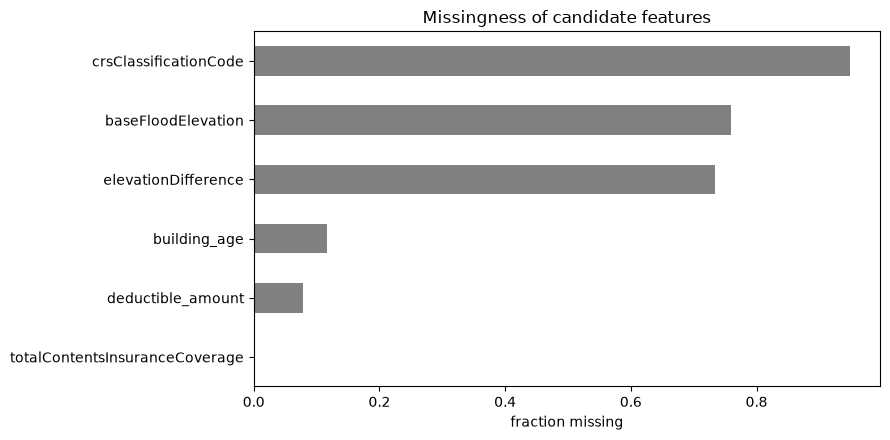

In [53]:
# how much is missing
# elevation fields mostly absent
miss = (
    model_df[
        [
            "elevationDifference",
            "baseFloodElevation",
            "building_age",
            "deductible_amount",
            "crsClassificationCode",
            "totalContentsInsuranceCoverage",
        ]
    ]
    .isna()
    .mean()
    .sort_values()
)
miss.plot(kind="barh", color="grey")
plt.xlabel("fraction missing")
plt.title("Missingness of candidate features")
plt.tight_layout()
plt.show()

## 7. Features and the leakage boundary

In [54]:
# leakage protection
# underwriting-time features only (present at underwriting)
# exclude everything post-flood to avoid leakage
NUMERIC = [
    "totalBuildingInsuranceCoverage",
    "totalContentsInsuranceCoverage",
    "deductible_amount",
    "building_age",
    "crsClassificationCode",
    "elevationDifference",
]
CATEG = [
    "zone_family",
    "occupancy_class",
    "state",
    "floors_cat",
    "basement_cat",
    "postFIRMConstructionIndicator_i",
    "elevatedBuildingIndicator_i",
    "primaryResidenceIndicator_i",
]
TARGET = "amountPaidOnBuildingClaim"

X = model_df[NUMERIC + CATEG].copy()
y = model_df[TARGET].astype(float).values

# excluded post-flood fields (using these would be leakage)
LEAKY = [
    "waterDepth",
    "floodWaterDuration",
    "causeOfDamage",
    "buildingDamageAmount",
    "netBuildingPaymentAmount",
    "floodEvent",
    "amountPaidOnContentsClaim",
]
print("features used   :", len(NUMERIC), "numeric +", len(CATEG), "categorical")
print("excluded (leaky):", ", ".join(LEAKY))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"\ntrain: {X_train.shape}   test: {X_test.shape}")

features used   : 6 numeric + 8 categorical
excluded (leaky): waterDepth, floodWaterDuration, causeOfDamage, buildingDamageAmount, netBuildingPaymentAmount, floodEvent, amountPaidOnContentsClaim

train: (17908, 14)   test: (4477, 14)


## 8. Preprocessing pipeline

In [55]:
# pipeline
#
# Monetary features get log1p BEFORE imputation/scaling
# With a log link raw-scaled heavy-tailed money lets the linear predictor
# extrapolate and exp() explode
# (reproduced in the 'post-mortem unstabilised GLM' section)
# When log()'d the GLM's effects become elasticities and predictions stay
# bounded
# > log1p handles zeros and passes NaN through to the imputer untouched.
from sklearn.preprocessing import FunctionTransformer

MONETARY_NUM = [
    "totalBuildingInsuranceCoverage",
    "totalContentsInsuranceCoverage",
    "deductible_amount",
]
OTHER_NUM = [c for c in NUMERIC if c not in MONETARY_NUM]

cat_pipe = Pipeline(
    [
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        (
            "money",
            Pipeline(
                [
                    # feature_names_out needed so SHAP can recover column names
                    (
                        "log1p",
                        FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
                    ),
                    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
                    ("scale", StandardScaler()),
                ]
            ),
            MONETARY_NUM,
        ),
        (
            "num",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
                    ("scale", StandardScaler()),
                ]
            ),
            OTHER_NUM,
        ),
        ("cat", cat_pipe, CATEG),
    ]
)
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('money', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

## 9. Models and a baseline to beat

| Model                                    | Family            |
| ---------------------------------------- | ----------------- |
| **Baseline - mean payout by flood zone** | trivial heuristic |
| **GLM (Gamma, log-link)**                | linear / GLM      |
| **GBM (gradient boosting, gamma loss)**  | tree ensemble     |


In [56]:
# helpers
from sklearn.metrics import d2_tweedie_score


def rmse(a, b):
    return mean_squared_error(a, b) ** 0.5


def score_row(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE ($)": mean_absolute_error(y_true, y_pred),
        "RMSE ($)": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        # D2 = variance-explained on the GAMMA-DEVIANCE scale — the
        # like-for-like score for models that optimise deviance (both of ours
        # do). R2 is a squared-error score and can be destroyed by a handful
        # of huge errors that deviance barely notices (see post-mortem).
        "D2 (gamma)": d2_tweedie_score(y_true, y_pred, power=2),
    }


def clip_at_coverage(y_pred, X):
    """Cap predictions at the policy's building coverage limit.

    A payout above the limit is contractually impossible, so this is a
    business rule, not a tuning trick. Rows with no recorded limit are left
    unclipped.
    """
    cap = X["totalBuildingInsuranceCoverage"].to_numpy(dtype=float)
    cap = np.where(np.isfinite(cap) & (cap > 0), cap, np.inf)
    return np.minimum(y_pred, cap)


# two real models (the baseline is computed directly in the next cell)
# Gamma GLM
glm = Pipeline(
    [
        ("prep", preprocess),
        ("glm", TweedieRegressor(power=2, link="log", alpha=3, max_iter=5000)),
    ]
)
gbm = Pipeline(
    [
        ("prep", preprocess),
        (
            "gbm",
            HistGradientBoostingRegressor(
                loss="gamma",
                learning_rate=0.05,
                max_iter=400,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
print("models defined")

models defined


## 10. Evaluation — random 80/20 split

In [57]:
# BE note:
# > local runtime on full data:     ~ 1m 10.4s
# > local runtime on sample data:   ~ 0m 02.3s
results = []

# Baseline
# mean payout by rated flood zone (legacy scheme), using TRAIN only (no leakage)
zone_mean = pd.Series(y_train, index=X_train["zone_family"]).groupby(level=0).mean()
baseline_pred = X_test["zone_family"].map(zone_mean).fillna(y_train.mean()).values
results.append(score_row("Baseline (zone mean)", y_test, baseline_pred))

# GLM
glm.fit(X_train, y_train)
results.append(
    score_row(
        "GLM (Gamma, log-link)", y_test, clip_at_coverage(glm.predict(X_test), X_test)
    )
)
# GBM
gbm.fit(X_train, y_train)
results.append(
    score_row("GBM (gamma loss)", y_test, clip_at_coverage(gbm.predict(X_test), X_test))
)

results_df = pd.DataFrame(results).set_index("Model")
print(results_df.round(2).to_string())

                        MAE ($)  RMSE ($)    R2  D2 (gamma)
Model                                                      
Baseline (zone mean)   51572.19  87581.43  0.02        0.04
GLM (Gamma, log-link)  48395.94  85788.55  0.06        0.10
GBM (gamma loss)       38684.57  73201.89  0.32        0.32


In [58]:
# BE note:
# > local runtime on full data:     ~ 4m 41.7s
# > local runtime on sample data:   ~ 0m 06.9s

# 5-fold cross-validated Mean Absolute Error
# > !not using test for tuning
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, est in [("GLM", glm), ("GBM", gbm)]:
    s = -cross_val_score(
        est, X_train, y_train, cv=cv, scoring="neg_mean_absolute_error"
    )
    print(f"CV MAE  {name}:  ${s.mean():,.0f}  ± ${s.std():,.0f}")

CV MAE  GLM:  $48,209  ± $1,345
CV MAE  GBM:  $37,818  ± $866


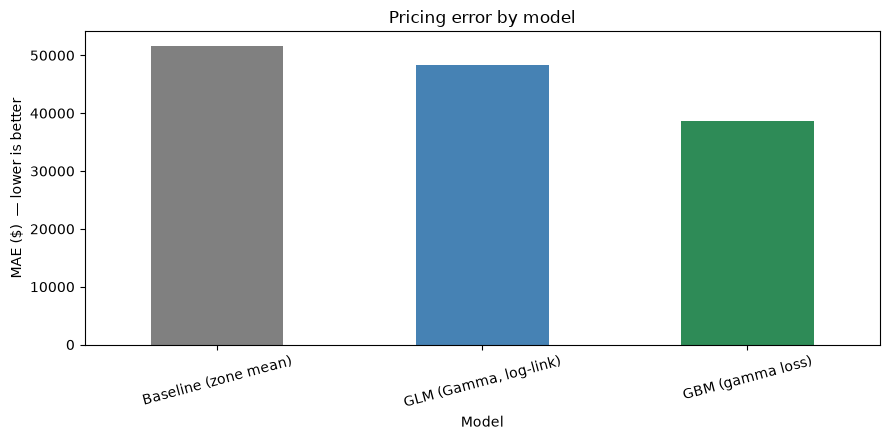

The GBM cuts average pricing error by 25% versus the legacy zone scheme.


,MAE ($),RMSE ($),R2,D2 (gamma)
Model,,,,
Baseline (zone mean),51572.190641,87581.431289,0.020651,0.041615
"GLM (Gamma, log-link)",48395.938432,85788.551754,0.060338,0.103659
GBM (gamma loss),38684.569386,73201.886875,0.315840,0.319924


In [59]:
# MAE by model (lower is better)
results_df["MAE ($)"].plot(kind="bar", color=["grey", "steelblue", "seagreen"])
plt.ylabel("MAE ($)  — lower is better")
plt.title("Pricing error by model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

b = results_df.loc["Baseline (zone mean)", "MAE ($)"]
g = results_df.loc["GBM (gamma loss)", "MAE ($)"]
print(
    f"The GBM cuts average pricing error by {(b-g)/b:.0%} versus the legacy zone scheme."
)

results_df

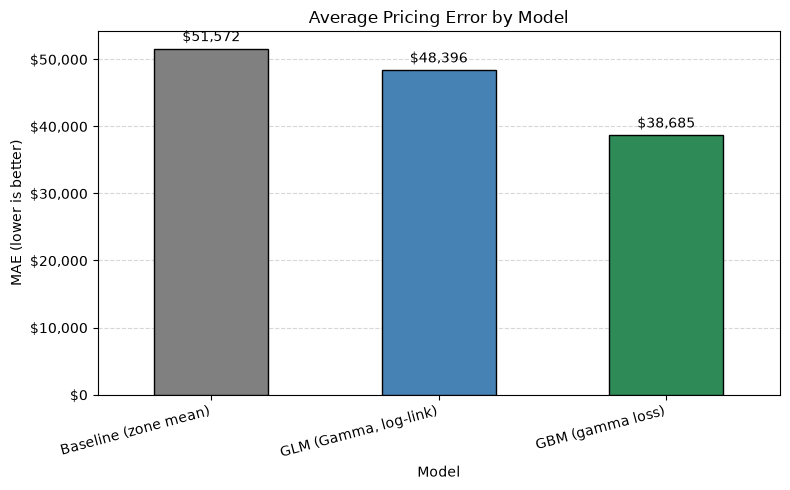


--- Model Impact ---
The GBM reduces average pricing error by 25.0% versus the legacy zone scheme
In absolute terms this is an improvement of $12,888 per claim on average


,MAE ($),RMSE ($),R2,D2 (gamma)
Model,,,,
Baseline (zone mean),51572.190641,87581.431289,0.020651,0.041615
"GLM (Gamma, log-link)",48395.938432,85788.551754,0.060338,0.103659
GBM (gamma loss),38684.569386,73201.886875,0.315840,0.319924


In [60]:
import matplotlib.ticker as ticker

ax = results_df["MAE ($)"].plot(
    kind="bar",
    color=["grey", "steelblue", "seagreen"],
    figsize=(8, 5), 
    edgecolor="black", 
    zorder=3, 
)

# top of bar labels
ax.bar_label(ax.containers[0], fmt="${:,.0f}", padding=3)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))

plt.ylabel("MAE (lower is better)")
plt.title("Average Pricing Error by Model")
plt.xticks(rotation=15, ha="right")  
plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
plt.tight_layout()
plt.show()

baseline_mae = results_df.loc["Baseline (zone mean)", "MAE ($)"]
gbm_mae = results_df.loc["GBM (gamma loss)", "MAE ($)"]

improvement_pct = (baseline_mae - gbm_mae) / baseline_mae
improvement_abs = baseline_mae - gbm_mae

print("\n--- Model Impact ---")
print(
    f"The GBM reduces average pricing error by {improvement_pct:.1%} versus the legacy zone scheme"
)
print(
    f"In absolute terms this is an improvement of ${improvement_abs:,.0f} per claim on average"
)
results_df

### Post-mortem - un-stabilised GLM

In [61]:
# post-mortem / validation
# Running the SAME Gamma GLM without the stabilisation
# (this was method used in the first draft)
# monetary features raw-scaled (no log1p) and predictions not clipped at the
# coverage limit
#
# Reproduced deliberately here as diagnosis is informative
# The mechanism:
#   1. a log-link GLM predicts exp(linear predictor)
#       raw heavy-tailed coverage is unbounded after scaling, so extreme rows
#       push the linear predictor past anything seen in training and exp()
#       turns that into an absurd prediction
#   2. R2 is a squared-error score
#       a few blown rows can make it explode while MAE (linear) barely moves
#   3. the GLM optimises gamma deviance, not squared error
#       > judged on D2 it is poor but not broken
#       > judged on R2 it can look catastrophic.
#       Metric choice is part of methodology, hence D2 on every scoreboard
naive_prep = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
                    ("scale", StandardScaler()),
                ]
            ),
            # all numerics raw-scaled, money included
            NUMERIC,  
        ),
        ("cat", cat_pipe, CATEG),
    ]
)
naive_glm = Pipeline(
    [
        ("prep", naive_prep),
        ("glm", TweedieRegressor(power=2, link="log", alpha=3, max_iter=5000)),
    ]
).fit(X_train, y_train)
# deliberately unclipped
naive_pred = naive_glm.predict(X_test)  

pm = pd.DataFrame(
    [
        score_row("GLM naive (raw-$, unclipped)", y_test, naive_pred),
        results_df.loc["GLM (Gamma, log-link)"].rename("x").to_dict()
        | {"Model": "GLM stabilised (log1p + clip)"},
    ]
).set_index("Model")
print(pm.round(4).to_string(), end="\n\n")

print(f"largest single naive prediction: ${naive_pred.max():,.0f}")
print(f"largest actual payout in test  : ${y_test.max():,.0f}")

                                  MAE ($)    RMSE ($)      R2  D2 (gamma)
Model                                                                    
GLM naive (raw-$, unclipped)   50515.6843  89056.3155 -0.0126      0.0611
GLM stabilised (log1p + clip)  48395.9384  85788.5518  0.0603      0.1037

largest single naive prediction: $1,001,053
largest actual payout in test  : $2,402,528


## 11. Out-of-time validation (train pre-2020, test 2020 onwards)

In [62]:
# out-of-time split:
#   train on losses before CUTOFF_YEAR, test on the rest.
# From genAI:
# The random split answers "can we price claims from events we have already
# seen?" - Hurricane Harvey's claims sit in both train and test.
# The committee's actual question is whether a model trained on the past can
# price NEXT year's book, so here the test years sit strictly after the
# training years, and CV folds are grouped by year so no fold ever contains
# its own year.
#
# BE note: this now means that the split share is set by the cutoff, not chosen
#
# The future differing from the past (different events, states, coding
# regimes, real severity trend) is what this measures
# Whilst we could rebalance or statify across the cutoff it would leak the
# future back in
# Legitimate checks are
# > (a) the test share is big enough for stable metrics (printed below) and
# > (b) the finding is not an artefact of one particular window
#   (the cutoff sweep in the next cell)
from sklearn.model_selection import GroupKFold

CUTOFF_YEAR = 2020
years = pd.to_numeric(model_df["yearOfLoss"], errors="coerce").to_numpy()

is_test = years >= CUTOFF_YEAR
X_train, X_test = X[~is_test], X[is_test]
y_train, y_test = y[~is_test], y[is_test]
print(
    f"train (< {CUTOFF_YEAR}): {len(X_train):,} rows   "
    f"test (>= {CUTOFF_YEAR}): {len(X_test):,} rows   "
    f"({is_test.mean():.0%} of claims)"
)
print("\nclaims per test year:")
print(pd.Series(years[is_test]).astype(int).value_counts().sort_index().to_string())

# year-grouped 5-fold CV on the training years
# precomputed as index pairs so every downstream 
# GridSearchCV / cross_val_score picks it up via cv= with no groups= plumbing
gkf = GroupKFold(n_splits=5)
cv = list(gkf.split(X_train, y_train, groups=years[~is_test]))

# zone baseline recomputed on this split (train only)
zone_mean = pd.Series(y_train, index=X_train["zone_family"]).groupby(level=0).mean()
baseline_pred = X_test["zone_family"].map(zone_mean).fillna(y_train.mean()).values

# refit the (untuned) models out-of-time
oot = [score_row("Baseline (zone mean)", y_test, baseline_pred)]
glm.fit(X_train, y_train)
oot.append(
    score_row(
        "GLM (Gamma, log-link)", y_test, clip_at_coverage(glm.predict(X_test), X_test)
    )
)
gbm.fit(X_train, y_train)
oot.append(
    score_row("GBM (gamma loss)", y_test, clip_at_coverage(gbm.predict(X_test), X_test))
)
oot_df = pd.DataFrame(oot).set_index("Model")
print("\n", oot_df.round(2).to_string())

# important: gap is the finding
# How much a naive random-split evaluation overstates deployable performance 
# (event memorisation + genuine drift)
gap = (oot_df["MAE ($)"] - results_df["MAE ($)"]).dropna()
print("\nMAE gap (out-of-time minus random split):")
print(gap.round(0).to_string())

train (< 2020): 19,971 rows   test (>= 2020): 2,414 rows   (11% of claims)

claims per test year:
2020    243
2021    420
2022    501
2023    160
2024    943
2025    135
2026     12

                         MAE ($)   RMSE ($)    R2  D2 (gamma)
Model                                                       
Baseline (zone mean)   63985.06  134076.18 -0.03       -0.08
GLM (Gamma, log-link)  63041.49  133208.24 -0.02       -0.04
GBM (gamma loss)       59794.27  129591.72  0.04       -0.03

MAE gap (out-of-time minus random split):
Model
Baseline (zone mean)     12413.0
GLM (Gamma, log-link)    14646.0
GBM (gamma loss)         21110.0


In [63]:
# robustness of the gap to the choice of window
# repeats the out-of-time evaluation at several cutoffs (GBM + baseline only)
#
# If the lift over the baseline holds across windows, the finding is not an
# artefact of which events happen to sit in one particular test set
#
# BE note: one GBM fit per cutoff
#   > minutes on the full data, seconds on sample
from sklearn.base import clone

sweep = []
for cut in [2016, 2018, 2020]:
    te = years >= cut
    m = clone(gbm).fit(X[~te], y[~te])
    pred = clip_at_coverage(m.predict(X[te]), X[te])
    zm = pd.Series(y[~te], index=X[~te]["zone_family"]).groupby(level=0).mean()
    base = X[te]["zone_family"].map(zm).fillna(y[~te].mean()).values
    sweep.append(
        {
            "cutoff": cut,
            "test share": f"{te.mean():.0%}",
            "baseline MAE ($)": mean_absolute_error(y[te], base),
            "GBM MAE ($)": mean_absolute_error(y[te], pred),
        }
    )
sweep_df = pd.DataFrame(sweep).set_index("cutoff")
sweep_df["GBM lift vs baseline"] = (
    1 - sweep_df["GBM MAE ($)"] / sweep_df["baseline MAE ($)"]
)
print(sweep_df.round(2).to_string())

       test share  baseline MAE ($)  GBM MAE ($)  GBM lift vs baseline
cutoff                                                                
2016          23%          61877.80     58351.45                  0.06
2018          14%          60067.18     54679.50                  0.09
2020          11%          63985.06     59794.27                  0.07


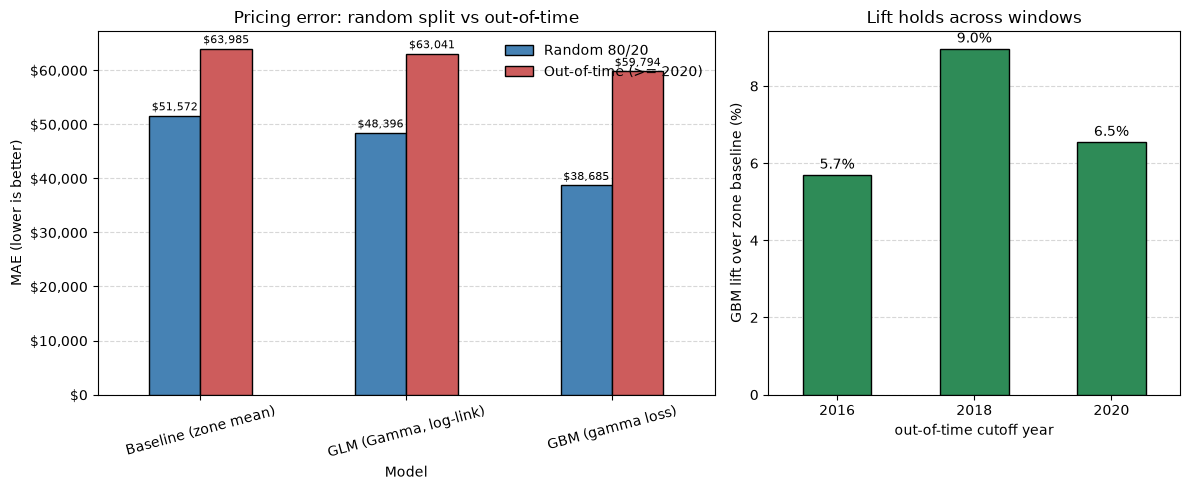

GBM lift over the zone baseline: 25% on the random split, 7% out-of-time.
The difference is the optimism of a naive evaluation
-> out-of-time number is the one to price on


In [64]:
# Left: MAE per model, random split vs out-of-time — the gap between the two
# bars is the optimism of a naive evaluation. Right: the GBM's lift over the
# zone baseline at each cutoff — if the bars are similar, the finding is not
# an artefact of one particular test window. Requires results_df, oot_df,
# sweep_df and CUTOFF_YEAR from the cells above.
# the gap, drawn: random-split vs out-of-time MAE, and lift robustness
import matplotlib.ticker as ticker

comp = pd.DataFrame(
    {
        "Random 80/20": results_df["MAE ($)"],
        f"Out-of-time (>= {CUTOFF_YEAR})": oot_df["MAE ($)"],
    }
).loc[oot_df.index]

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [3, 2]}
)

comp.plot(
    kind="bar", ax=ax1, color=["steelblue", "indianred"], edgecolor="black", zorder=3
)
for cont in ax1.containers:
    ax1.bar_label(cont, fmt="${:,.0f}", padding=2, fontsize=8)
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
ax1.set_ylabel("MAE (lower is better)")
ax1.set_title("Pricing error: random split vs out-of-time")
ax1.tick_params(axis="x", rotation=15)
ax1.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
ax1.legend(frameon=False)

(sweep_df["GBM lift vs baseline"] * 100).plot(
    kind="bar", ax=ax2, color="seagreen", edgecolor="black", zorder=3
)
ax2.bar_label(ax2.containers[0], fmt="{:.1f}%", padding=2)
ax2.set_ylabel("GBM lift over zone baseline (%)")
ax2.set_xlabel("out-of-time cutoff year")
ax2.set_title("Lift holds across windows")
ax2.tick_params(axis="x", rotation=0)
ax2.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)

plt.tight_layout()
plt.show()

lift_random = 1 - (
    results_df.loc["GBM (gamma loss)", "MAE ($)"]
    / results_df.loc["Baseline (zone mean)", "MAE ($)"]
)
lift_oot = 1 - (
    oot_df.loc["GBM (gamma loss)", "MAE ($)"]
    / oot_df.loc["Baseline (zone mean)", "MAE ($)"]
)
print(
    f"GBM lift over the zone baseline: {lift_random:.0%} on the random split, "
    f"{lift_oot:.0%} out-of-time."
)
print("The difference is the optimism of a naive evaluation")
print("-> out-of-time number is the one to price on")

## 12. Tuning

In [ ]:
# tuning the models — cross-validated, cached, with the full search record
# BE note:
# > local runtime on full data:     ~ TBC
# > local runtime on sample data:   ~ 3m 14.8s (cache load is ~1.4s)
# The search is the expensive step, so its outcome is persisted and reruns
# just load it and fit each model once. Cache is keyed by dataset mode
# ("_oot": tuned on the out-of-time training set with year-grouped CV).
# 
# Set FORCE_RETUNE = True to repeat the search.
from sklearn.base import clone
import sklearn

TUNED_PARAMS = Path("models/tuned_params.json")
FORCE_RETUNE = False
mode_key = ("sample" if USE_SAMPLE else "full") + "_oot"

cache = json.loads(TUNED_PARAMS.read_text()) if TUNED_PARAMS.exists() else {}
entry = {} if FORCE_RETUNE else cache.get(mode_key, {})


def _best_params(entry, name):
    """Read the reload params from either the new record shape or the old flat one."""
    node = entry[name]
    return (
        node["best_params"]
        if isinstance(node, dict) and "best_params" in node
        else node
    )


if entry:
    print(f"loaded cached tuning record [{mode_key}] from {TUNED_PARAMS}")
    print(
        f"  tuned {entry.get('tuned_at', 'unknown')}  "
        f"on {entry.get('n_train', 0):,} rows  "
        f"(cutoff {entry.get('cutoff_year', '?')}, "
        f"sklearn {entry.get('sklearn', '?')})"
    )
    for name in ["glm", "gbm"]:
        node = entry[name]
        if isinstance(node, dict) and "best_cv_mae" in node:
            print(
                f"  {name.upper()} best CV MAE: ${node['best_cv_mae']:,.0f}   "
                f"params: {node['best_params']}"
            )

    # staleness check: the cache can't be trusted if the training data changed
    if entry.get("n_train") not in (None, len(X_train)) or entry.get(
        "cutoff_year"
    ) not in (None, CUTOFF_YEAR):
        print(
            "  WARNING: cached record was tuned on different data "
            f"({entry.get('n_train', '?'):,} rows, cutoff {entry.get('cutoff_year', '?')}; "
            f"current: {len(X_train):,} rows, cutoff {CUTOFF_YEAR}) — "
            "set FORCE_RETUNE = True to refresh."
        )

    glm_best = clone(glm).set_params(**_best_params(entry, "glm")).fit(X_train, y_train)
    gbm_best = clone(gbm).set_params(**_best_params(entry, "gbm")).fit(X_train, y_train)
else:
    # GLM: cross-validate the regularisation strength
    glm_search = GridSearchCV(
        glm,
        {"glm__alpha": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]},
        scoring="neg_mean_absolute_error",
        cv=cv,
    )
    glm_search.fit(X_train, y_train)
    print("GLM best alpha:", glm_search.best_params_["glm__alpha"])

    # GBM: small randomised search
    gbm_search = RandomizedSearchCV(
        gbm,
        {
            "gbm__learning_rate": [0.03, 0.05, 0.1, 0.15, 0.2],
            "gbm__max_leaf_nodes": [31, 63, 127, 255],
            "gbm__max_iter": [300, 500, 800, 1200],
            "gbm__l2_regularization": [0.0, 0.1, 1.0, 10.0],
            "gbm__min_samples_leaf": [5, 10, 20, 50, 100],
        },
        n_iter=25,
        scoring="neg_mean_absolute_error",
        cv=cv,
        random_state=RANDOM_STATE,
    )
    gbm_search.fit(X_train, y_train)
    print(
        "GBM best params:",
        {k.replace("gbm__", ""): v for k, v in gbm_search.best_params_.items()},
    )

    glm_best = glm_search.best_estimator_
    gbm_best = gbm_search.best_estimator_

    # full search record -> one CSV per model: every candidate with its
    # params, mean/std CV MAE, per-fold scores, and fit times. This is the
    # evidence that the winner was (or wasn't) decisively better than the
    # field, and doubles as an appendix artefact.
    for name, search in [("glm", glm_search), ("gbm", gbm_search)]:
        out = Path(f"models/cv_results_{mode_key}_{name}.csv")
        out.parent.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(search.cv_results_).to_csv(out, index=False)
        print(f"saved full CV results -> {out}")

    def record(search, step):
        """Tuning record for one model: reload params + provenance + audit trail."""
        fitted = search.best_estimator_.named_steps[step]
        return {
            "best_params": search.best_params_,  # the searched dims (used to reload)
            "best_cv_mae": float(-search.best_score_),
            "n_candidates": len(search.cv_results_["params"]),
            # EVERY hyperparameter of the fitted regressor, searched or not —
            # if the notebook's model definition later drifts, this shows what
            # the cached params were actually tuned against
            "full_estimator_params": {
                k: v
                for k, v in fitted.get_params().items()
                if isinstance(v, (int, float, str, bool, type(None)))
            },
        }

    cache[mode_key] = {
        "tuned_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "n_train": int(len(X_train)),
        "cutoff_year": int(CUTOFF_YEAR),
        "scoring": "neg_mean_absolute_error",
        "cv": "5-fold year-grouped (no fold contains its own year)",
        "sklearn": sklearn.__version__,
        "glm": record(glm_search, "glm"),
        "gbm": record(gbm_search, "gbm"),
    }
    TUNED_PARAMS.parent.mkdir(parents=True, exist_ok=True)
    TUNED_PARAMS.write_text(json.dumps(cache, indent=2))
    print(f"saved tuning record [{mode_key}] -> {TUNED_PARAMS}")

# refresh the scoreboard with the tuned models (test metrics stay out of the
# cache file: the tuning record is CV-only, the scoreboard is reporting)
tuned = [
    score_row("Baseline (zone mean)", y_test, baseline_pred),
    score_row(
        "GLM (tuned)", y_test, clip_at_coverage(glm_best.predict(X_test), X_test)
    ),
    score_row(
        "GBM (tuned)", y_test, clip_at_coverage(gbm_best.predict(X_test), X_test)
    ),
]
tuned_df = pd.DataFrame(tuned).set_index("Model")
print("\n", tuned_df.round(3).to_string())
best_model = gbm_best  # used for interpretation and pricing below

GLM best alpha: 0.03
GBM best params: {'min_samples_leaf': 5, 'max_leaf_nodes': 63, 'max_iter': 1200, 'learning_rate': 0.15, 'l2_regularization': 10.0}
saved full CV results -> models/cv_results_sample_oot_glm.csv
saved full CV results -> models/cv_results_sample_oot_gbm.csv
saved tuning record [sample_oot] -> models/tuned_params.json

                         MAE ($)    RMSE ($)     R2  D2 (gamma)
Model                                                         
Baseline (zone mean)  63985.065  134076.182 -0.031      -0.084
GLM (tuned)           62443.141  130838.714  0.018       0.013
GBM (tuned)           60112.254  129417.273  0.039      -0.149


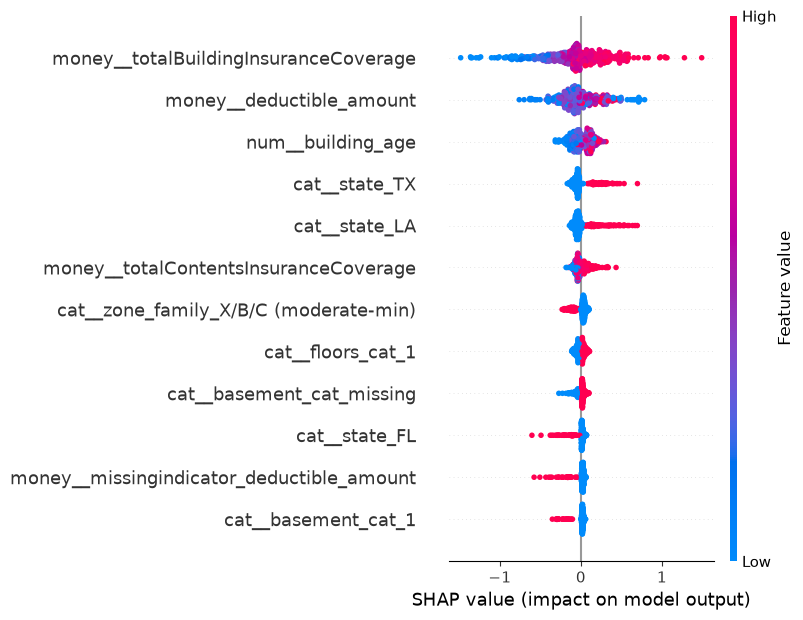

In [66]:
# sample of the training rows for speed.
Xt = best_model.named_steps["prep"].transform(X_train)
feature_names = best_model.named_steps["prep"].get_feature_names_out()
explainer = shap.TreeExplainer(best_model.named_steps["gbm"])
shap_values = explainer.shap_values(Xt[:500])
shap.summary_plot(
    shap_values, Xt[:500], feature_names=feature_names, show=True, max_display=12
)

In [67]:
# Get importance ranking
# mean absolute SHAP value
importance = (
    pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)
    .sort_values(ascending=False)
    .head(10)
)
print("Top drivers (mean |SHAP|):")
print(importance.to_string())

Top drivers (mean |SHAP|):
money__totalBuildingInsuranceCoverage    0.304142
money__deductible_amount                 0.178578
num__building_age                        0.096047
cat__state_TX                            0.087852
cat__state_LA                            0.086255
money__totalContentsInsuranceCoverage    0.059035
cat__zone_family_X/B/C (moderate-min)    0.054696
cat__floors_cat_1                        0.039505
cat__basement_cat_missing                0.037387
cat__state_FL                            0.037127


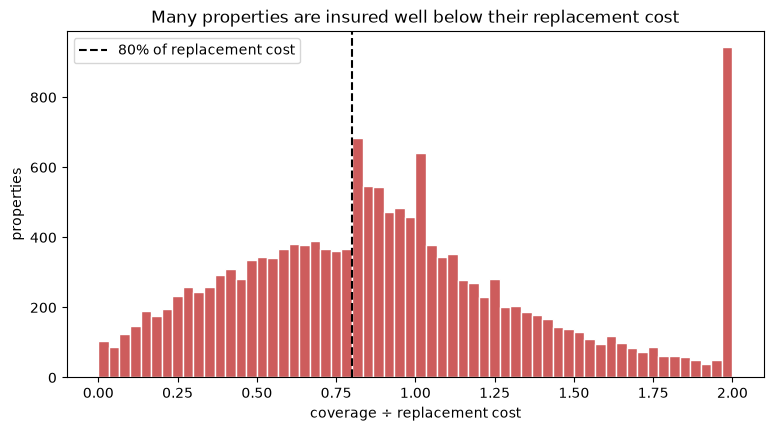

properties assessed       : 15,778
median coverage/replacement: 0.88
under-insured (<80%)       : 41%
severely under-insured(<50%): 20%


In [68]:
# behaviour explore
# coverage vs replacement cost - just where both are present
rc = pd.to_numeric(model_df["buildingReplacementCost"], errors="coerce")
cov = model_df["totalBuildingInsuranceCoverage"]
ok = rc.notna() & cov.notna() & (rc > 0)
ratio = (cov[ok] / rc[ok]).clip(upper=2)  # coverage as a fraction of replacement cost

plt.hist(ratio, bins=60, color="indianred", edgecolor="white")
plt.axvline(0.8, color="black", ls="--", label="80% of replacement cost")
plt.xlabel("coverage ÷ replacement cost")
plt.ylabel("properties")
plt.legend()
plt.title("Many properties are insured well below their replacement cost")
plt.show()

print(f"properties assessed       : {int(ok.sum()):,}")
print(f"median coverage/replacement: {ratio.median():.2f}")
print(f"under-insured (<80%)       : {(ratio < 0.8).mean():.0%}")
print(f"severely under-insured(<50%): {(ratio < 0.5).mean():.0%}")

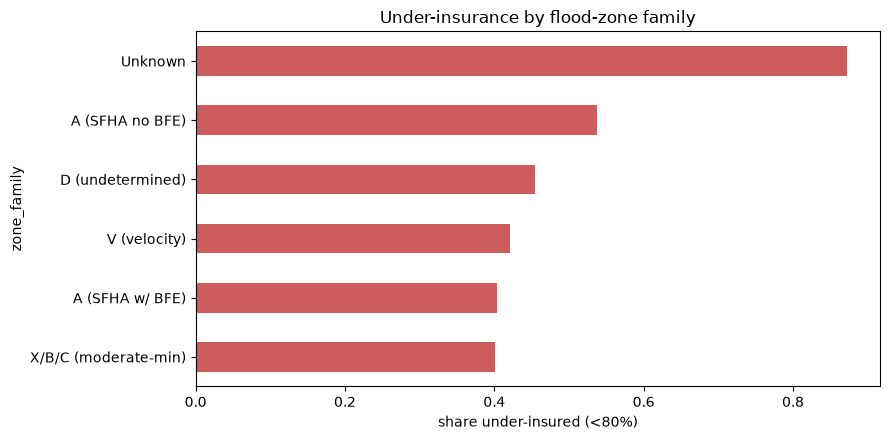

In [69]:
# Which segments are most under-insured? (share below 80% of replacement cost, by flood zone)
seg = (ratio < 0.8).groupby(model_df.loc[ok, "zone_family"]).mean().sort_values()
seg.plot(kind="barh", color="indianred")
plt.xlabel("share under-insured (<80%)")
plt.title("Under-insurance by flood-zone family")
plt.tight_layout()
plt.show()

In [72]:
# Model-implied severity for every modelled property, vs the flat zone-average it is priced at today
model_df = model_df.copy()
model_df["pred_severity"] = best_model.predict(X)

# Focus on the largest zone and show the within-zone spread the flat rate ignores
zone = model_df["zone_family"].value_counts().idxmax()
sub = model_df[model_df["zone_family"] == zone]
zone_flat = sub[
    "amountPaidOnBuildingClaim"
].mean()  # what flat zone pricing charges everyone here
deciles = sub["pred_severity"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(0)

print(f"Largest zone: {zone}  (flat zone severity = ${zone_flat:,.0f})")
print("Model-implied severity within this zone (deciles):")
print(deciles.to_string())
rel = deciles / zone_flat
print("\nImplied relativity to the flat zone rate:")
print(rel.round(2).to_string())
print(
    f"\n=> Within this zone the top-decile risk carries ~{rel.loc[0.9]:.1f}x the flat "
    f"zone rate, and ~{deciles.loc[0.9] / deciles.loc[0.1]:.1f}x the bottom-decile "
    f"risk — differentiation the flat rate misses."
)

Largest zone: A (SFHA w/ BFE)  (flat zone severity = $59,812)
Model-implied severity within this zone (deciles):
0.10     14299.0
0.25     21406.0
0.50     33746.0
0.75     62566.0
0.90    103939.0

Implied relativity to the flat zone rate:
0.10    0.24
0.25    0.36
0.50    0.56
0.75    1.05
0.90    1.74

=> Within this zone the top-decile risk carries ~1.7x the flat zone rate, and ~7.3x the bottom-decile risk — differentiation the flat rate misses.
